# Ejercicio 9

Codifique un script que reciba como parámetro el nombre de un archivo de texto, tokenize y calcule y escriba a un archivo los pares (#términos totales procesados, #términos únicos). Verifique en qué medida satisface la ley de Heaps. Grafique en la notebook los ajustes variando los parámetros de la expresión. Puede inicialmente probar con los archivos de los puntos anteriores.

## 1. Importar

In [23]:
import re
import numpy as np
import matplotlib.pyplot as plt

## 2. Lectura de salida.txt

In [24]:
datos =  np.loadtxt("salida.txt")
N = datos[:,0]
V = datos[:,1]

print("Tokens", N)
print("Vocabulario", V)

Tokens [1.000e+02 2.000e+02 3.000e+02 ... 3.864e+05 3.865e+05 3.866e+05]
Vocabulario [   62.   106.   150. ... 23511. 23537. 23561.]


## 3. Ley de Hops con polyfit

In [25]:
# Escala log
log_N = np.log(N)
log_V = np.log(V)

# Ajuste de polyfit
b, log_K = np.polyfit(log_N, log_V, 1)
K = np.exp(log_K)

print(f"K = {K:.4f}")
print(f"b = {b:.4f}")

K = 7.8604
b = 0.6236


## 4.1 Grafico lineal

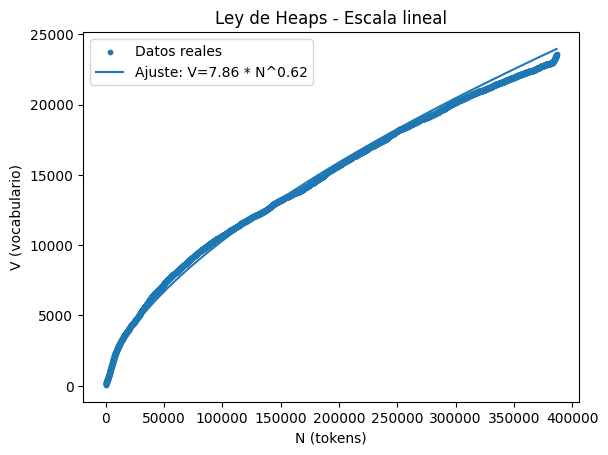

In [26]:
plt.figure()

plt.scatter(N, V, s=10, label="Datos reales")

ajuste = K * (N ** b)
plt.plot(N, ajuste, label=f"Ajuste: V={K:.2f} * N^{b:.2f}")

plt.xlabel("N (tokens)")
plt.ylabel("V (vocabulario)")
plt.title("Ley de Heaps - Escala lineal")
plt.legend()

plt.show()

## 4.2 Grafico Log-Log

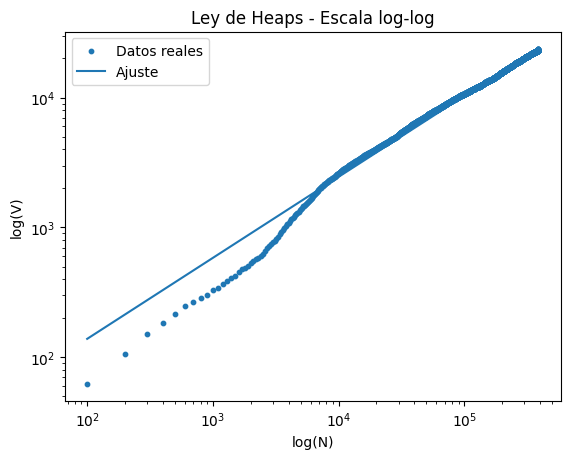

In [27]:
plt.figure()

plt.scatter(N, V, s=10, label="Datos reales")
plt.plot(N, ajuste, label="Ajuste")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("log(N)")
plt.ylabel("log(V)")
plt.title("Ley de Heaps - Escala log-log")
plt.legend()

plt.show()

## 5 Variacion de parametros

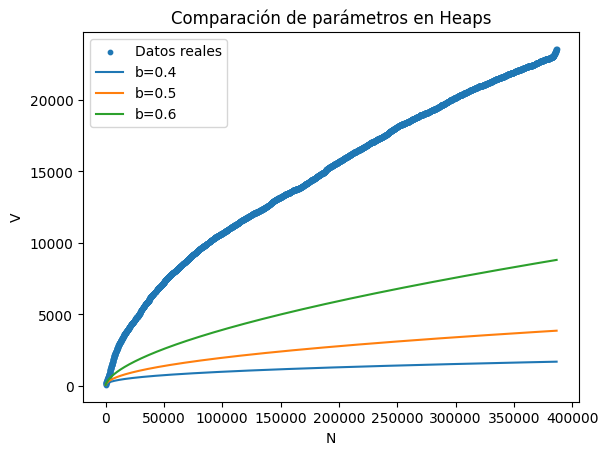

In [28]:
plt.figure()

plt.scatter(N, V, s=10, label="Datos reales")

# distintos valores de b
for b_test in [0.4, 0.5, 0.6]:
    K_test = V[0] / (N[0] ** b_test)
    curva = K_test * (N ** b_test)
    
    plt.plot(N, curva, label=f"b={b_test}")

plt.xlabel("N")
plt.ylabel("V")
plt.title("Comparación de parámetros en Heaps")
plt.legend()

plt.show()